# First need to import some necessary libraries 

In [107]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Here I need to do some feature engineering

In [108]:
data  = pd.read_csv(r"cleaned_students_performance.csv")
df = data.copy()

In [109]:
df.head()

,gender,race_ethnicity,parent's_education,lunch_type,prep_course,math_score,reading_score,writing_score
0,1,1,4,0,0,72,72,74
1,1,2,2,0,1,69,90,88
2,1,1,5,0,0,90,95,93
3,0,0,3,1,0,47,57,44
4,0,2,2,0,0,76,78,75


In [110]:
df.tail()

,gender,race_ethnicity,parent's_education,lunch_type,prep_course,math_score,reading_score,writing_score
995,1,4,5,0,1,88,99,95
996,0,2,1,1,0,62,55,55
997,1,2,1,1,1,59,71,65
998,1,3,2,0,1,68,78,77
999,1,3,2,1,0,77,86,86


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gender              1000 non-null   int64
 1   race_ethnicity      1000 non-null   int64
 2   parent's_education  1000 non-null   int64
 3   lunch_type          1000 non-null   int64
 4   prep_course         1000 non-null   int64
 5   math_score          1000 non-null   int64
 6   reading_score       1000 non-null   int64
 7   writing_score       1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


In [112]:
df.describe()

,gender,race_ethnicity,parent's_education,lunch_type,prep_course,math_score,reading_score,writing_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.518000,2.174000,2.081000,0.355000,0.358000,66.08900,69.169000,68.054000
std,0.499926,1.157179,1.460333,0.478753,0.479652,15.16308,14.600192,15.195657
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,57.00000,59.000000,57.750000
50%,1.000000,2.000000,2.000000,0.000000,0.000000,66.00000,70.000000,69.000000
75%,1.000000,3.000000,3.000000,1.000000,1.000000,77.00000,79.000000,79.000000
max,1.000000,4.000000,5.000000,1.000000,1.000000,100.00000,100.000000,100.000000


# I going to create new attribute such as mean number and total number

In [113]:
df['total_score']= df['math_score']+df['reading_score']+df['writing_score']
df['mean_score'] = df['total_score']/3
df['result'] = df['total_score'].apply(lambda x: 'invalid' if  x<0  else 'fail' if x<150 else 'good' if x>=150 and x<241 else 'excellent' if x>=240 and x<270 else 'outstanding' if x>=270 and x<301 else 'invalid')

In [114]:
df.head()

,gender,race_ethnicity,parent's_education,lunch_type,prep_course,math_score,reading_score,writing_score,total_score,mean_score,result
0,1,1,4,0,0,72,72,74,218,72.666667,good
1,1,2,2,0,1,69,90,88,247,82.333333,excellent
2,1,1,5,0,0,90,95,93,278,92.666667,outstanding
3,0,0,3,1,0,47,57,44,148,49.333333,fail
4,0,2,2,0,0,76,78,75,229,76.333333,good


# Lets find out some special students 

In [115]:
math_full_mark_passed = df[(df['math_score']==100) & (df['result']!='invalid') & (df['result']!='fail')].value_counts().sum()
reading_full_mark_passed = df[(df['reading_score']==100) & (df['result']!='invalid') & (df['result']!='fail')].value_counts().sum()
writing_full_mark_passed = df[(df['writing_score']==100) & (df['result']!='invalid') & (df['result']!='fail')].value_counts().sum()
full_mark_all_subjects = df[df['mean_score']==100].value_counts().sum()
print(f"Number of students who passed with full marks in math: {math_full_mark_passed}")
print(f"Number of students who passed with full marks in reading: {reading_full_mark_passed}")
print(f"Number of students who passed with full marks in writing: {writing_full_mark_passed}")
print(f"Total number of students who got full marks in a specific subject and passed all subjects: {math_full_mark_passed + reading_full_mark_passed + writing_full_mark_passed}")
print(f"Total number of students who got full marks in all subjects and passed: {full_mark_all_subjects}")

Number of students who passed with full marks in math: 7
Number of students who passed with full marks in reading: 17
Number of students who passed with full marks in writing: 14
Total number of students who got full marks in a specific subject and passed all subjects: 38
Total number of students who got full marks in all subjects and passed: 3


# Lets find out some potential students who needs little bit help 

In [116]:
full_math_mark_failed =df[(df['math_score']==100) & (df['result'] == 'fail')].value_counts().sum()
full_reading_mark_failed = df[(df['reading_score']==100) & (df['result'] == 'fail')].value_counts().sum()
full_writing_mark_failed = df[(df['writing_score']==100) & (df['result'] == 'fail')].value_counts().sum()
print(f"Number of students who got full marks in math but failed: {full_math_mark_failed}")
print(f"Number of students who got full marks in reading but failed: {full_reading_mark_failed}")
print(f"Number of students who got full marks in writing but failed: {full_writing_mark_failed}")

Number of students who got full marks in math but failed: 0
Number of students who got full marks in reading but failed: 0
Number of students who got full marks in writing but failed: 0


# Every high mark achiver is also good for  other subjects as well

# Lets find out who really needs help

In [117]:
number_of_failed_students =df[df['result']== 'fail'].value_counts().sum()
print(f"Total number of students who failed: {number_of_failed_students}")

Total number of students who failed: 103


# Now I want to visualize the important phonomena

In [118]:
df2 = pd.DataFrame({
    'data': [math_full_mark_passed, reading_full_mark_passed, writing_full_mark_passed, full_mark_all_subjects, number_of_failed_students,(df.shape[0]-number_of_failed_students)],
    'columns': ['Math Full Mark Passed', 'Reading Full Mark Passed', 'Writing Full Mark Passed', 'Full Mark All Subjects', 'Failed Students', 'Passed Students']
})
df2

,data,columns
0,7,Math Full Mark Passed
1,17,Reading Full Mark Passed
2,14,Writing Full Mark Passed
3,3,Full Mark All Subjects
4,103,Failed Students
5,897,Passed Students


In [119]:
df2.shape

(6, 2)

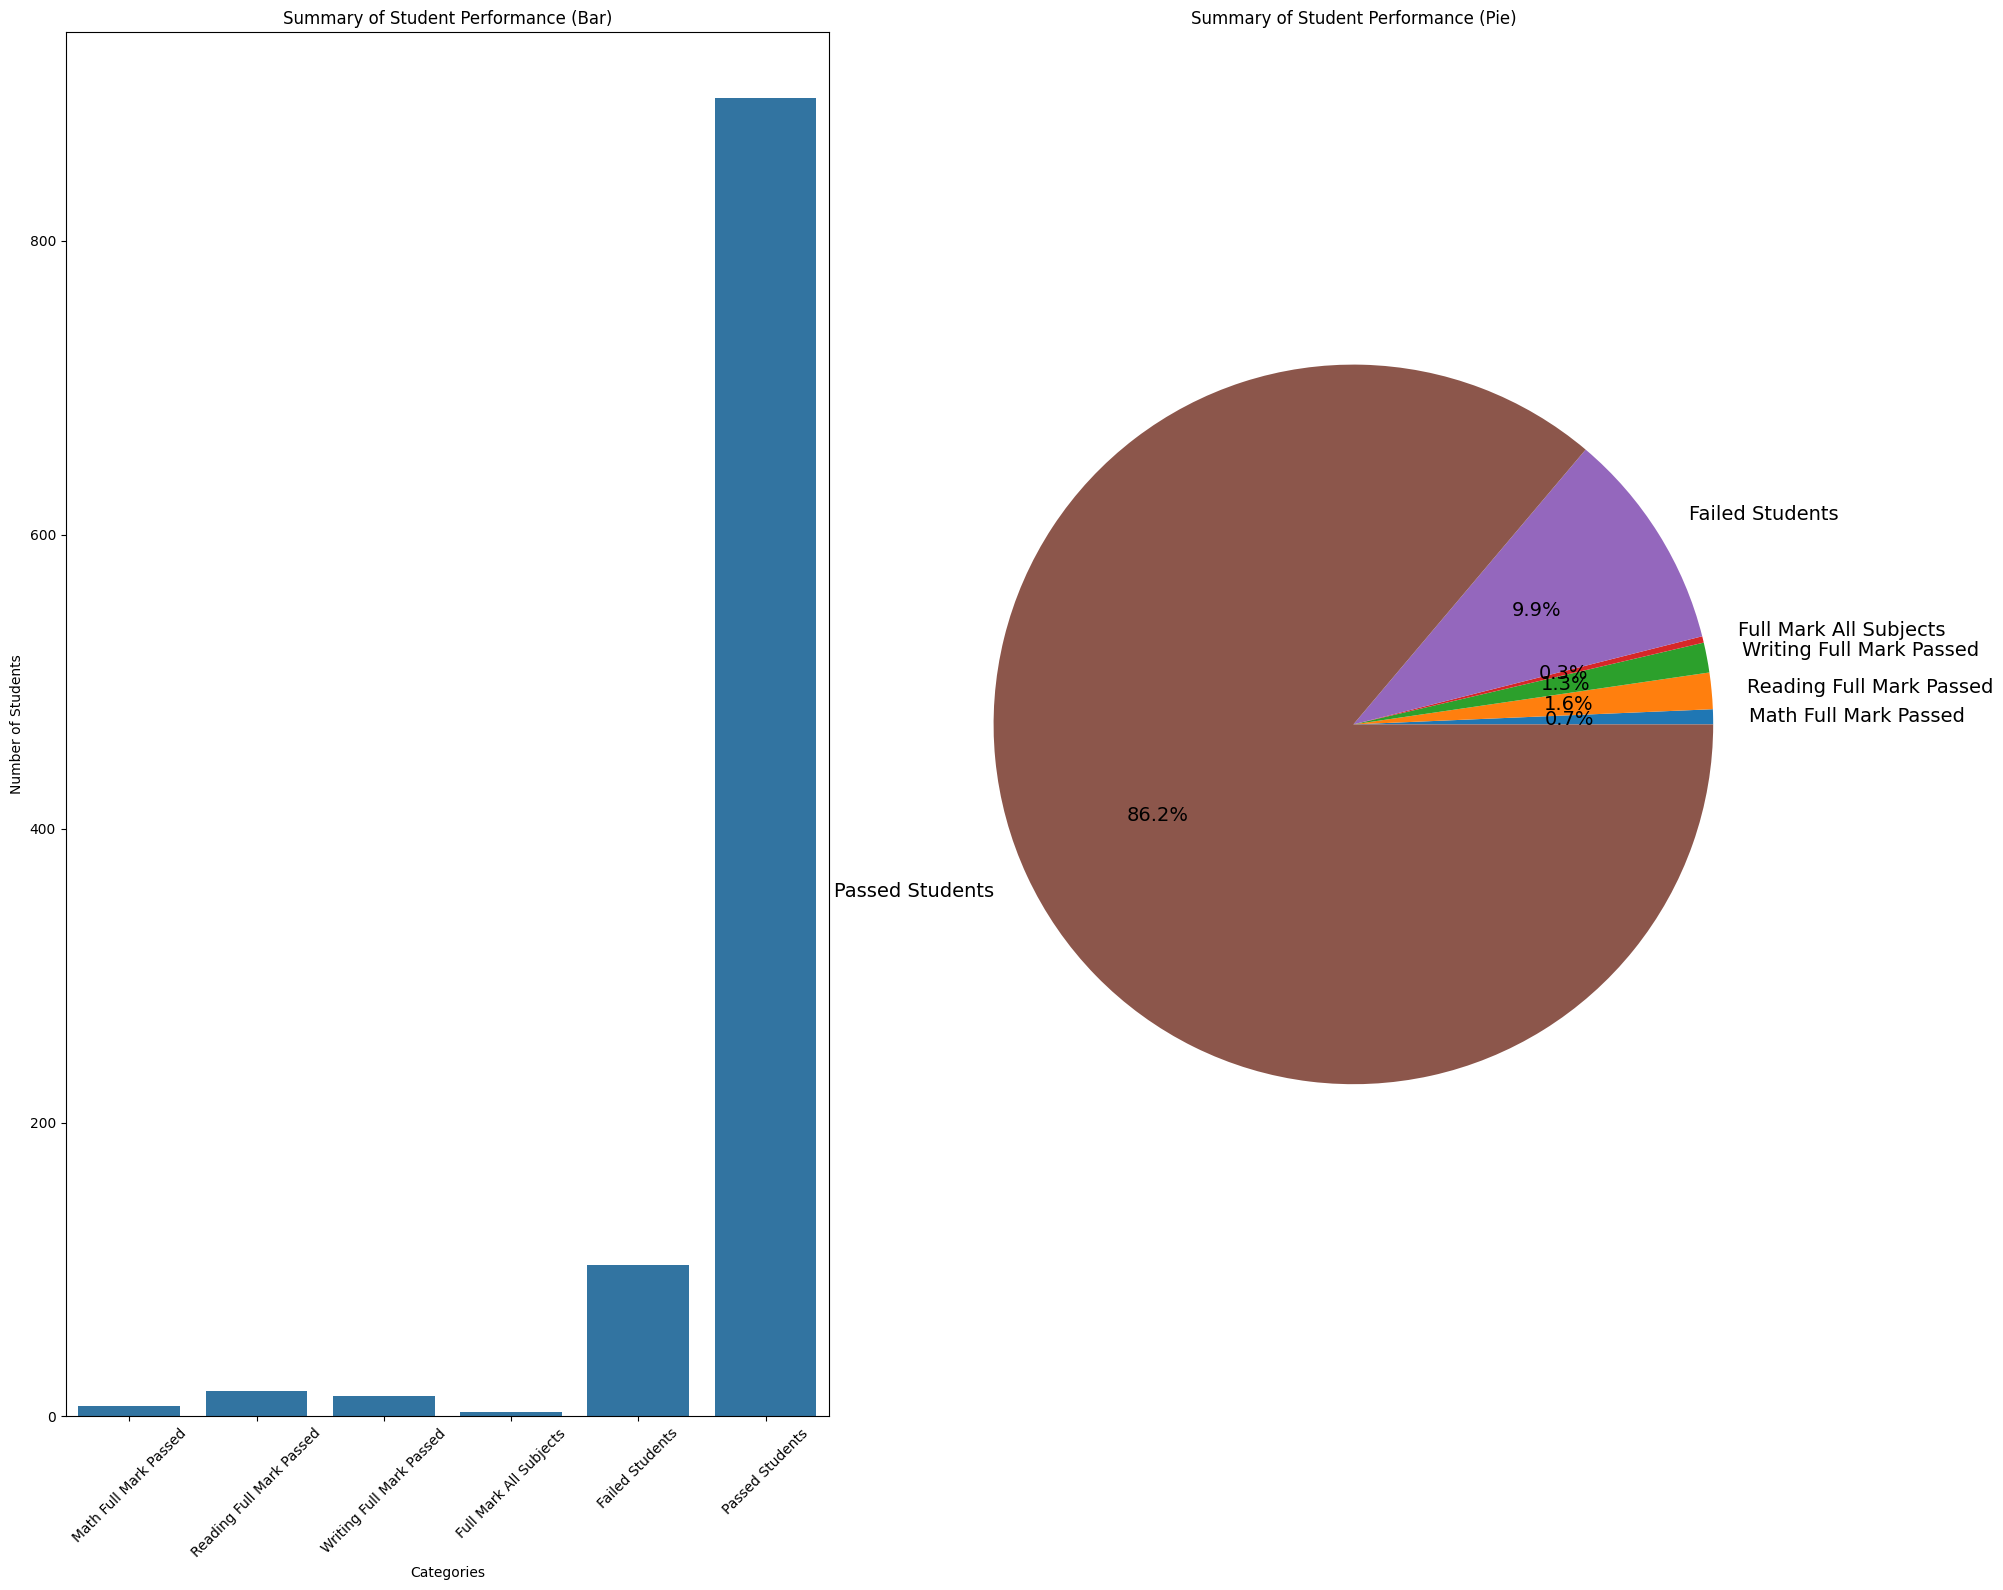

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(20, 16))
sns.barplot(x='columns', y='data', data=df2, ax=axes[0])
axes[0].set_xlabel('Categories')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Summary of Student Performance (Bar)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(
    df2['data'],
    labels=df2['columns'],
    autopct='%1.1f%%',
    textprops={'fontsize': 14}
 )
axes[1].set_title('Summary of Student Performance (Pie)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

# Now It is time for feature selection

In [121]:
df.columns

Index(['gender', 'race_ethnicity', 'parent's_education', 'lunch_type',
       'prep_course', 'math_score', 'reading_score', 'writing_score',
       'total_score', 'mean_score', 'result'],
      dtype='object')

In [122]:
df['result'].value_counts()

result
good           703
excellent      142
fail           103
outstanding     52
Name: count, dtype: int64

In [123]:
X = df[['gender','race_ethnicity', "parent's_education", "lunch_type", 'prep_course']]
y = df['result']

In [124]:
print("X type :"+ str(type(X)))
print("y type :"+ str(type(y)))

X type :<class 'pandas.core.frame.DataFrame'>
y type :<class 'pandas.core.series.Series'>


# Now lets check the distribution

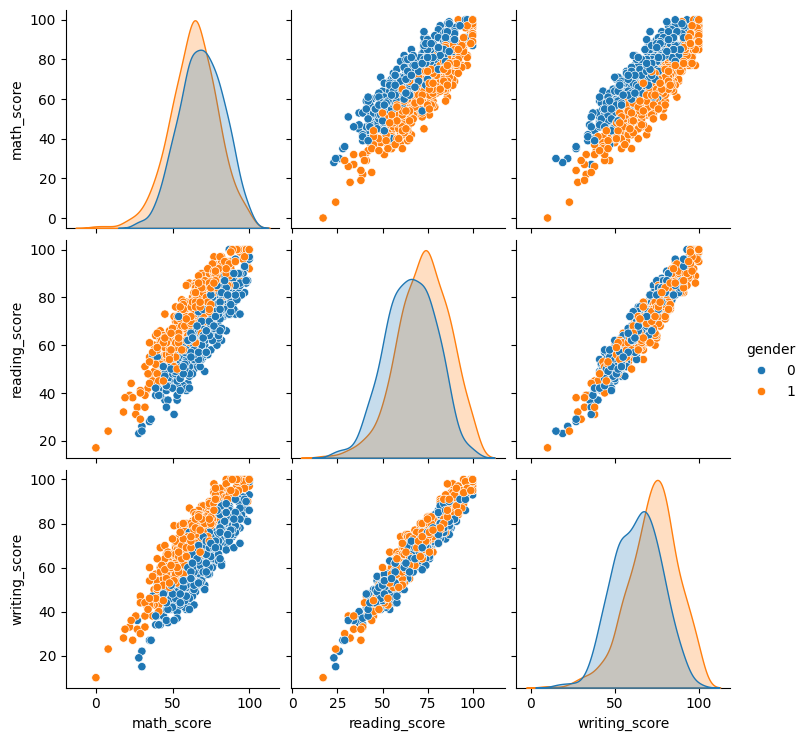

In [125]:
sns.pairplot(df, hue='gender', vars=['math_score', 'reading_score', 'writing_score'])

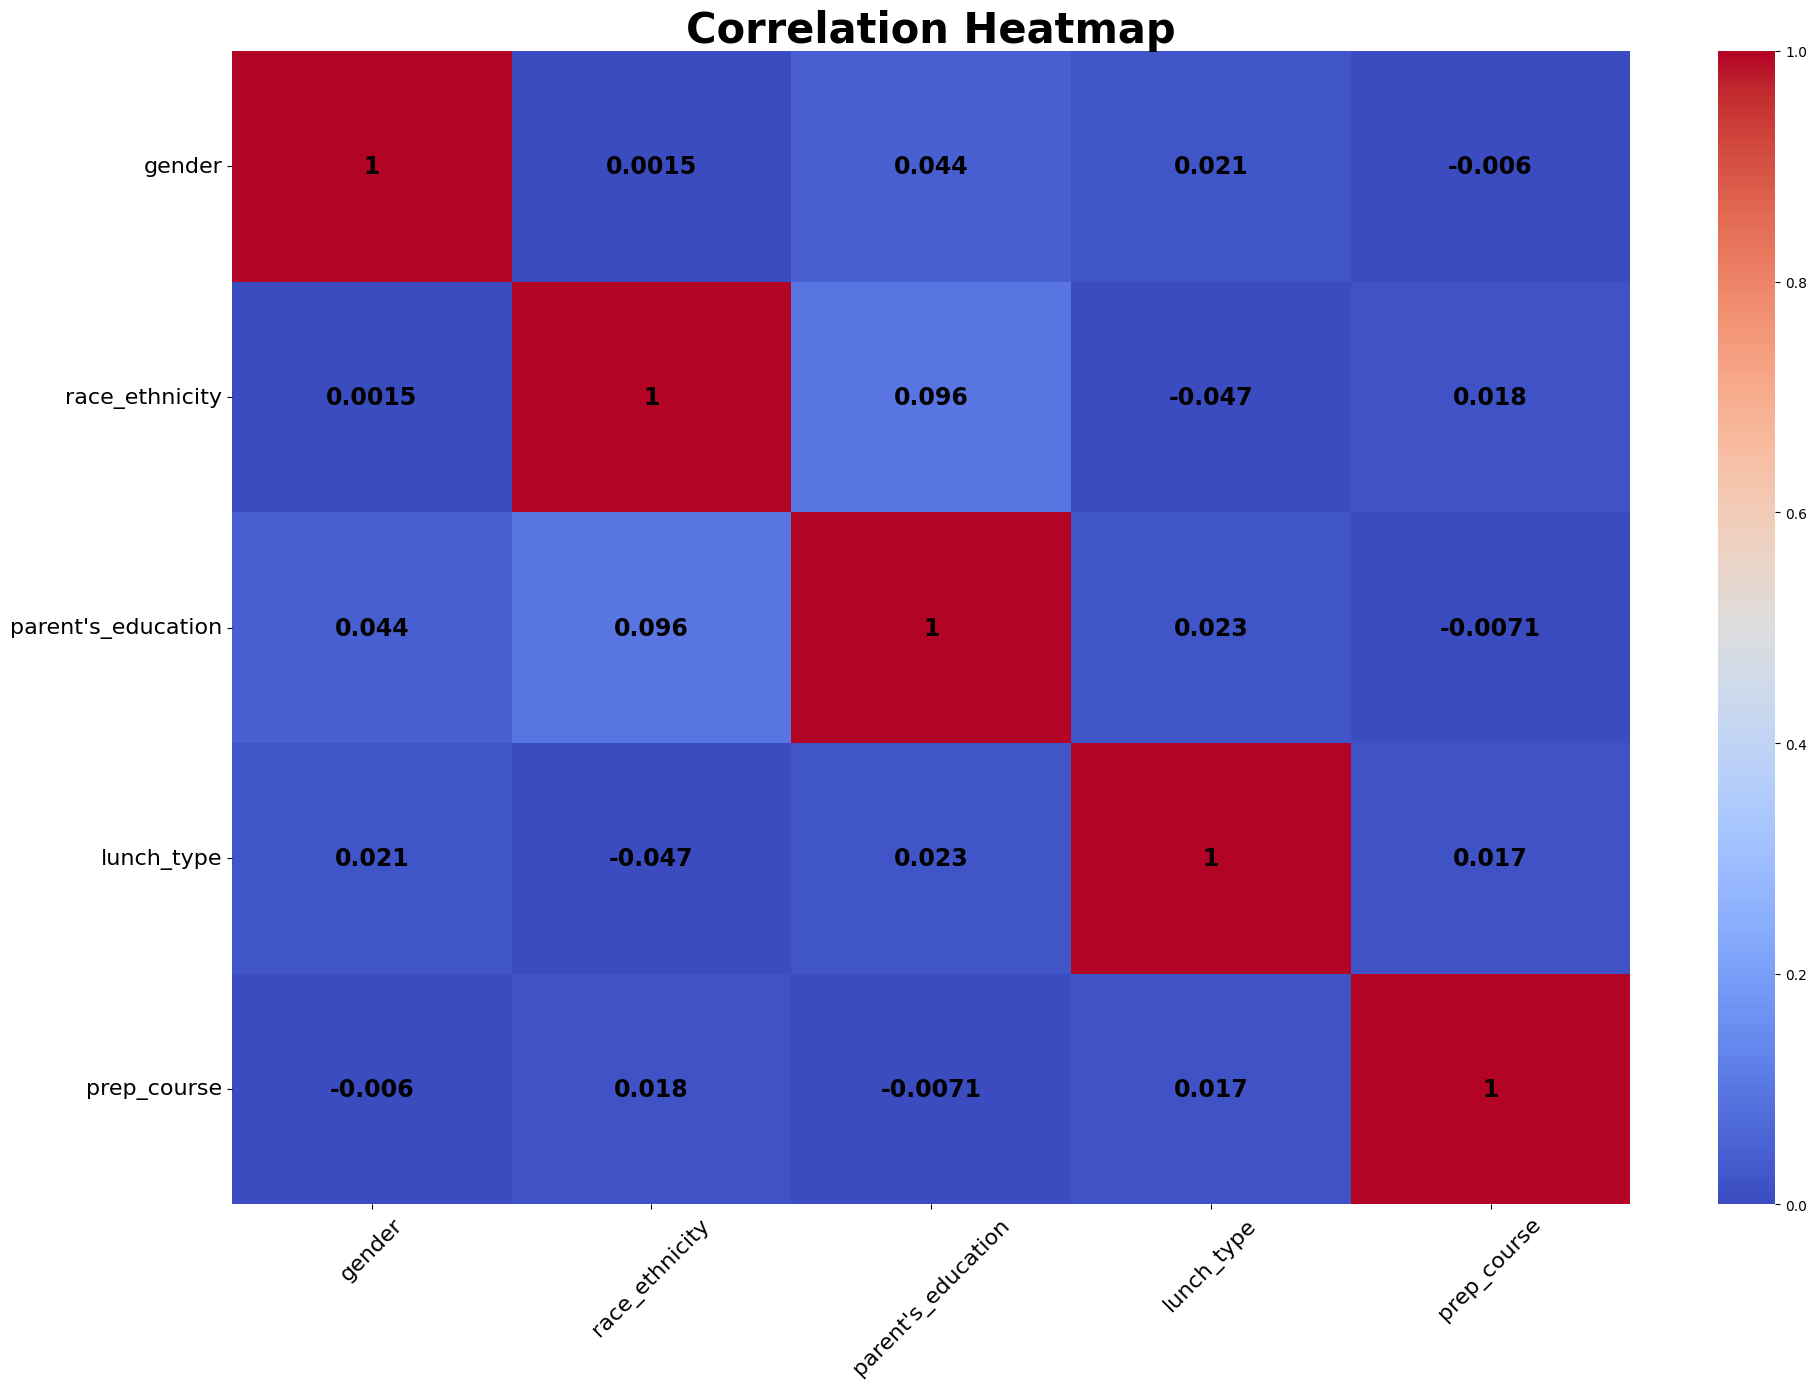

In [126]:
def correlation_visualization(df):
    plt.figure(figsize=(20, 14))
    sns.heatmap(
        df.corr(),
        annot=True,
         cmap='coolwarm', 
        cbar=True, 
         annot_kws={"size": 17, "weight": "bold", "color": "black"},
        vmin=0,
        vmax=1
         )
    plt.title('Correlation Heatmap', fontsize=30, weight='bold')
    plt.xticks(rotation=45, fontsize=16)
    plt.yticks(rotation=0, fontsize=16)
    plt.tight_layout()
    plt.show()
correlation_visualization(X)

In [127]:
colums = X.columns.tolist()
for col in colums:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 50)

Unique values in column 'gender':
[1 0]
--------------------------------------------------
Unique values in column 'race_ethnicity':
[1 2 0 3 4]
--------------------------------------------------
Unique values in column 'parent's_education':
[4 2 5 3 1 0]
--------------------------------------------------
Unique values in column 'lunch_type':
[0 1]
--------------------------------------------------
Unique values in column 'prep_course':
[0 1]
--------------------------------------------------


# now comes train test split

In [128]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Now here I want to do One hot encoding for features like parents education and race ethnicity columns

In [129]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Multi-category columns → One-Hot Encoding
ohe_features = ["parent's_education", 'race_ethnicity']

# Binary / low-cardinality columns → Ordinal Encoding
ordinal_features = ['gender', 'lunch_type', 'prep_course']

# Numeric columns → pass through as-is


preprocessor = ColumnTransformer(transformers=[
    ('ohe',     OneHotEncoder(handle_unknown='ignore'), ohe_features),
    ('ordinal', OrdinalEncoder(),                       ordinal_features)
])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded  = preprocessor.transform(X_test)

In [130]:
X_train_encoded

array([[0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 1., ..., 1., 0., 1.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 0.]])

# Now need to do the lable encoding for target category which is here the y means the result column

In [131]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Before getting to the training step I would like to dump my enconders into pkl

In [132]:
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

# Now its time for training and testing some model

**Importing the necessary libraries**

In [133]:
# The distance-based models (KNN, SVM) and the linear model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# The tree-based model and ensemble methods
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#evaluation metrics
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score, 
                             classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve, auc)

In [134]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    macro_precision = precision_score(y_test, y_pred, average='macro')
    macro_recall = recall_score(y_test, y_pred, average='macro')
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    classification_rep = classification_report(y_test, y_pred) 
    print("="*50)
    print()
    print(f"Accuracy for {model.__class__.__name__}: {accuracy}")
    print(f"Macro Precision for {model.__class__.__name__}: {macro_precision}")
    print(f"Macro Recall for {model.__class__.__name__}: {macro_recall}")
    print(f"Macro F1 Score for {model.__class__.__name__}: {macro_f1}")
    print(f"Classification Report for {model.__class__.__name__}:\n")  
    print(classification_rep)
    print(f"Visual Confusion Matrix for {model.__class__.__name__}:")  
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt='d',
        cmap='viridis',
        xticklabels=np.unique(y_test),  # ✅ numpy array has no .unique(); use np.unique()
        yticklabels=np.unique(y_test)
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()
    print()
    print("="*50)

In [135]:
dist_models = {
    "logistic_regression": LogisticRegression(class_weight='balanced'),
    "support_vector_machine": SVC(class_weight='balanced'),
    "k_nearest_neighbors": KNeighborsClassifier() 
}

tree_models = {
    "decision_tree": DecisionTreeClassifier(class_weight='balanced'),
    "random_forest": RandomForestClassifier(class_weight='balanced'),
    "gradient_boosting": GradientBoostingClassifier(), 
    "adaboost": AdaBoostClassifier(),
    "xgboost": XGBClassifier(scale_pos_weight=1), 
    "lightgbm": LGBMClassifier(), 
    "catboost": CatBoostClassifier(verbose=0)  
}

Training the distance bases model started LogisticRegression...

Accuracy for LogisticRegression: 0.31666666666666665
Macro Precision for LogisticRegression: 0.3165839645480006
Macro Recall for LogisticRegression: 0.45541277280011455
Macro F1 Score for LogisticRegression: 0.2831773217844509
Classification Report for LogisticRegression:

              precision    recall  f1-score   support

           0       0.19      0.29      0.23        41
           1       0.25      0.58      0.35        43
           2       0.72      0.25      0.37       206
           3       0.10      0.70      0.18        10

    accuracy                           0.32       300
   macro avg       0.32      0.46      0.28       300
weighted avg       0.56      0.32      0.34       300

Visual Confusion Matrix for LogisticRegression:


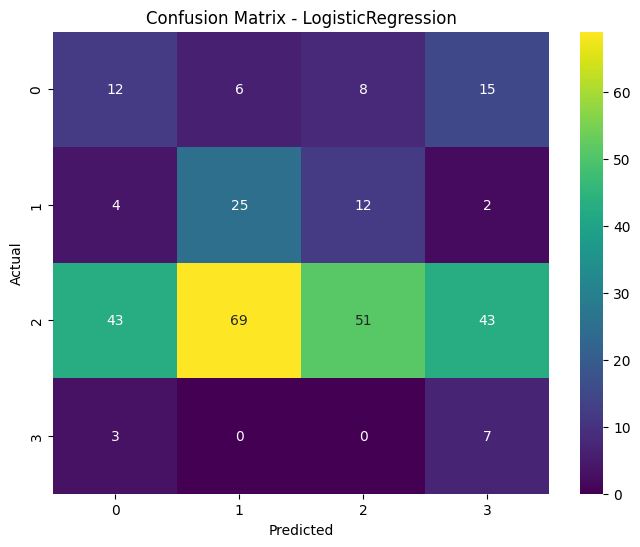


Training the distance bases model started SVC...

Accuracy for SVC: 0.35
Macro Precision for SVC: 0.3180555555555556
Macro Recall for SVC: 0.43024481108437185
Macro F1 Score for SVC: 0.2959582442190572
Classification Report for SVC:

              precision    recall  f1-score   support

           0       0.22      0.32      0.26        41
           1       0.23      0.49      0.32        43
           2       0.72      0.32      0.44       206
           3       0.10      0.60      0.17        10

    accuracy                           0.35       300
   macro avg       0.32      0.43      0.30       300
weighted avg       0.56      0.35      0.39       300

Visual Confusion Matrix for SVC:


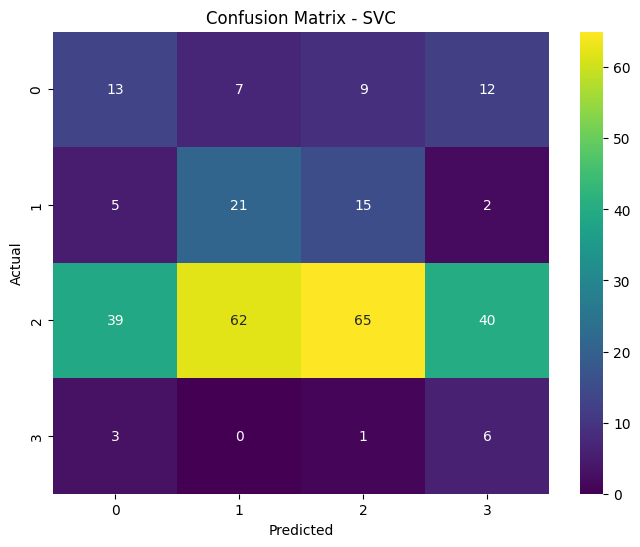


Training the distance bases model started KNeighborsClassifier...

Accuracy for KNeighborsClassifier: 0.6133333333333333
Macro Precision for KNeighborsClassifier: 0.2556025369978858
Macro Recall for KNeighborsClassifier: 0.25663792961027376
Macro F1 Score for KNeighborsClassifier: 0.2465965669435144
Classification Report for KNeighborsClassifier:

              precision    recall  f1-score   support

           0       0.20      0.10      0.13        41
           1       0.14      0.07      0.09        43
           2       0.69      0.86      0.76       206
           3       0.00      0.00      0.00        10

    accuracy                           0.61       300
   macro avg       0.26      0.26      0.25       300
weighted avg       0.52      0.61      0.56       300

Visual Confusion Matrix for KNeighborsClassifier:


c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-pa

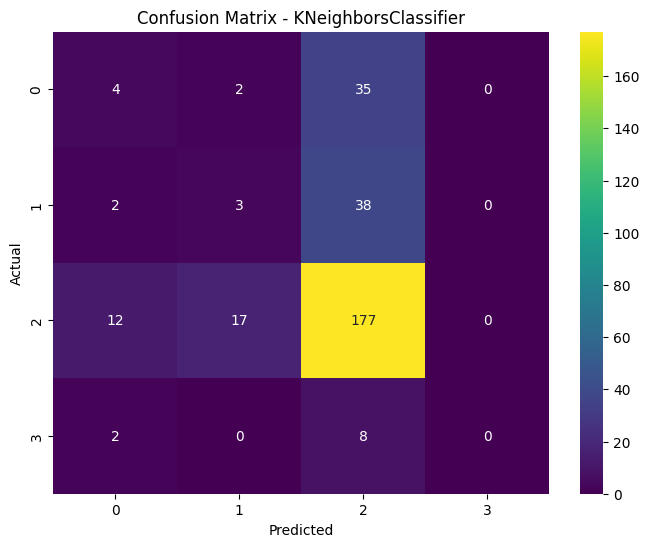

In [136]:
for name, model in dist_models.items():
    print(f"Training the distance bases model started {model.__class__.__name__}...")
    model.fit(X_train_encoded, y_train_encoded)
    evaluate_model(model, X_test_encoded, y_test_encoded)

Training the tree model started DecisionTreeClassifier...

Accuracy for DecisionTreeClassifier: 0.37333333333333335
Macro Precision for DecisionTreeClassifier: 0.2849625239994093
Macro Recall for DecisionTreeClassifier: 0.35776396147343725
Macro F1 Score for DecisionTreeClassifier: 0.26883915507144396
Classification Report for DecisionTreeClassifier:

              precision    recall  f1-score   support

           0       0.13      0.15      0.14        41
           1       0.22      0.37      0.27        43
           2       0.71      0.41      0.52       206
           3       0.08      0.50      0.14        10

    accuracy                           0.37       300
   macro avg       0.28      0.36      0.27       300
weighted avg       0.54      0.37      0.42       300

Visual Confusion Matrix for DecisionTreeClassifier:


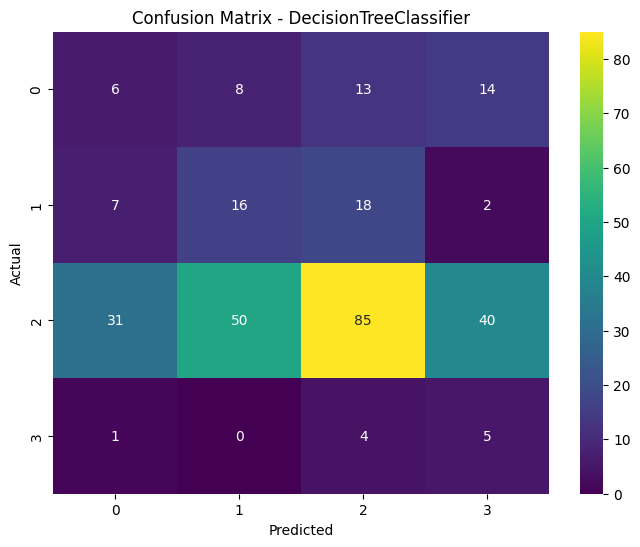


Training the tree model started RandomForestClassifier...

Accuracy for RandomForestClassifier: 0.4633333333333333
Macro Precision for RandomForestClassifier: 0.3028061224489796
Macro Recall for RandomForestClassifier: 0.37269672171772517
Macro F1 Score for RandomForestClassifier: 0.3051711252735201
Classification Report for RandomForestClassifier:

              precision    recall  f1-score   support

           0       0.19      0.20      0.19        41
           1       0.20      0.23      0.22        43
           2       0.70      0.56      0.63       206
           3       0.11      0.50      0.19        10

    accuracy                           0.46       300
   macro avg       0.30      0.37      0.31       300
weighted avg       0.54      0.46      0.49       300

Visual Confusion Matrix for RandomForestClassifier:


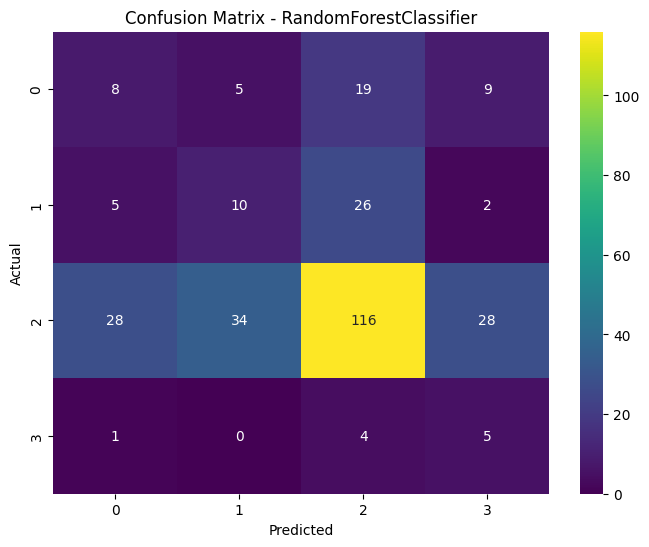


Training the tree model started GradientBoostingClassifier...

Accuracy for GradientBoostingClassifier: 0.6733333333333333
Macro Precision for GradientBoostingClassifier: 0.17235494880546076
Macro Recall for GradientBoostingClassifier: 0.24514563106796117
Macro F1 Score for GradientBoostingClassifier: 0.20240480961923848
Classification Report for GradientBoostingClassifier:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.00      0.00      0.00        43
           2       0.69      0.98      0.81       206
           3       0.00      0.00      0.00        10

    accuracy                           0.67       300
   macro avg       0.17      0.25      0.20       300
weighted avg       0.47      0.67      0.56       300

Visual Confusion Matrix for GradientBoostingClassifier:


c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-pa

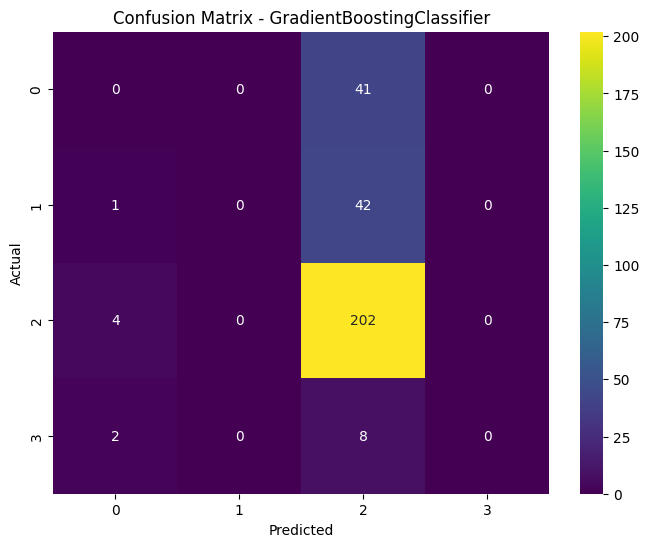


Training the tree model started AdaBoostClassifier...

Accuracy for AdaBoostClassifier: 0.59
Macro Precision for AdaBoostClassifier: 0.30998825753236336
Macro Recall for AdaBoostClassifier: 0.44033077444118307
Macro F1 Score for AdaBoostClassifier: 0.3495423816088899
Classification Report for AdaBoostClassifier:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.32      0.42      0.36        43
           2       0.71      0.74      0.73       206
           3       0.21      0.60      0.31        10

    accuracy                           0.59       300
   macro avg       0.31      0.44      0.35       300
weighted avg       0.54      0.59      0.56       300

Visual Confusion Matrix for AdaBoostClassifier:


c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Public\My projects\venv\lib\site-pa

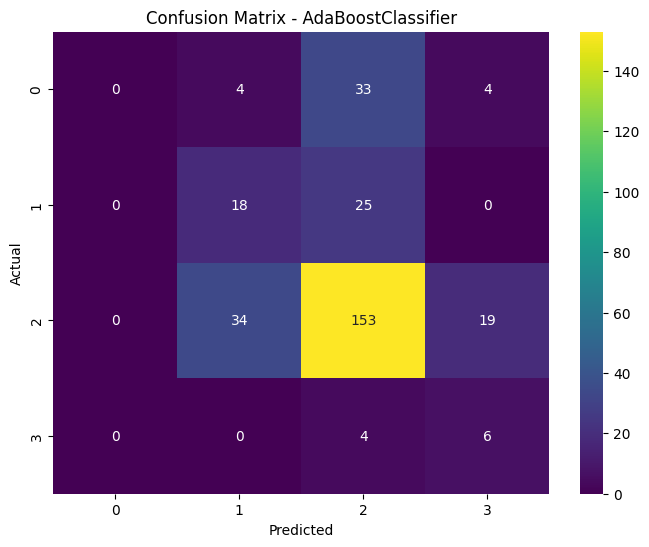


Training the tree model started XGBClassifier...


c:\Users\Public\My projects\venv\lib\site-packages\xgboost\core.py:158: UserWarning: [17:13:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)



Accuracy for XGBClassifier: 0.6266666666666667
Macro Precision for XGBClassifier: 0.2810167910447761
Macro Recall for XGBClassifier: 0.2657428313389027
Macro F1 Score for XGBClassifier: 0.25523084153206443
Classification Report for XGBClassifier:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.19      0.07      0.10        43
           2       0.69      0.89      0.78       206
           3       0.25      0.10      0.14        10

    accuracy                           0.63       300
   macro avg       0.28      0.27      0.26       300
weighted avg       0.51      0.63      0.55       300

Visual Confusion Matrix for XGBClassifier:


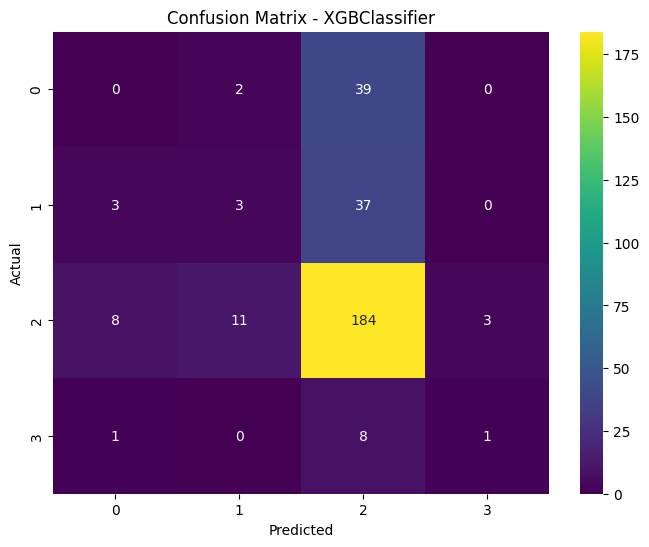


Training the tree model started LGBMClassifier...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 14
[LightGBM] [Info] Start training from score -1.935960
[LightGBM] [Info] Start training from score -2.456736
[LightGBM] [Info] Start training from score -0.342490
[LightGBM] [Info] Start training from score -2.813411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

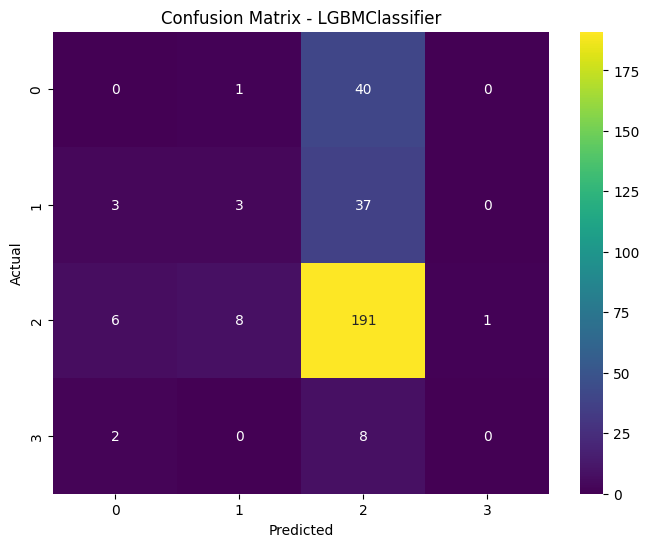


Training the tree model started CatBoostClassifier...

Accuracy for CatBoostClassifier: 0.6366666666666667
Macro Precision for CatBoostClassifier: 0.2795673076923077
Macro Recall for CatBoostClassifier: 0.2693836080379318
Macro F1 Score for CatBoostClassifier: 0.25572574217971705
Classification Report for CatBoostClassifier:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.23      0.07      0.11        43
           2       0.69      0.91      0.78       206
           3       0.20      0.10      0.13        10

    accuracy                           0.64       300
   macro avg       0.28      0.27      0.26       300
weighted avg       0.51      0.64      0.56       300

Visual Confusion Matrix for CatBoostClassifier:


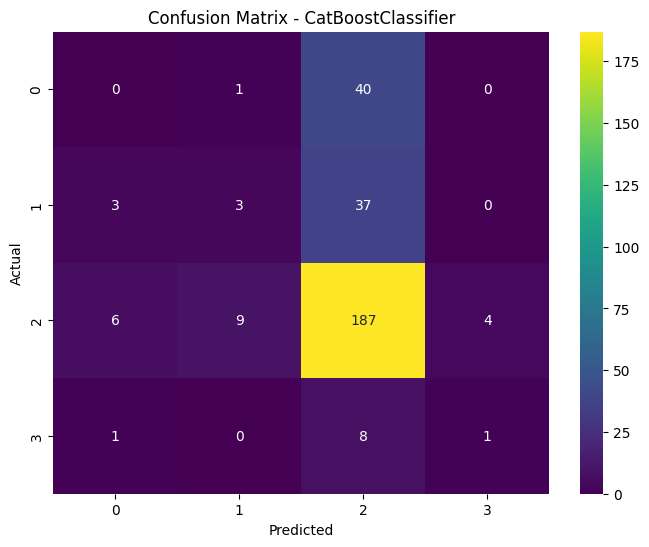

In [137]:
for name, model in tree_models.items():
    print(f"Training the tree model started {model.__class__.__name__}...")
    model.fit(X_train_encoded, y_train_encoded)
    evaluate_model(model, X_test_encoded, y_test_encoded)
    

In [138]:
from sklearn.metrics import accuracy_score, f1_score

all_models = {**dist_models, **tree_models}
results = []

for name, model in all_models.items():
    y_pred = model.predict(X_test_encoded)
    acc    = accuracy_score(y_test_encoded, y_pred)
    f1     = f1_score(y_test_encoded, y_pred, average='macro')
    results.append({'Model': model.__class__.__name__, 'Key': name, 'Accuracy': acc, 'Macro F1': f1})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())
print()
print("🥇 Best model  :", results_df.loc[1, 'Model'], f"(Accuracy={results_df.loc[1, 'Accuracy']:.4f})")
print("🥈 Runner-up   :", results_df.loc[2, 'Model'], f"(Accuracy={results_df.loc[2, 'Accuracy']:.4f})")

                         Model                     Key  Accuracy  Macro F1
1   GradientBoostingClassifier       gradient_boosting  0.673333  0.202405
2               LGBMClassifier                lightgbm  0.646667  0.225406
3           CatBoostClassifier                catboost  0.636667  0.255726
4                XGBClassifier                 xgboost  0.626667  0.255231
5         KNeighborsClassifier     k_nearest_neighbors  0.613333  0.246597
6           AdaBoostClassifier                adaboost  0.590000  0.349542
7       RandomForestClassifier           random_forest  0.463333  0.305171
8       DecisionTreeClassifier           decision_tree  0.373333  0.268839
9                          SVC  support_vector_machine  0.350000  0.295958
10          LogisticRegression     logistic_regression  0.316667  0.283177

🥇 Best model  : GradientBoostingClassifier (Accuracy=0.6733)
🥈 Runner-up   : LGBMClassifier (Accuracy=0.6467)


# Best Model: GradientBoostingClassifier
GradientBoosting is the clear winner. Saving it for use in the prediction pipeline.

In [140]:
best_model = tree_models['gradient_boosting']
joblib.dump(best_model, 'best_model.pkl')
print(f"Best model saved: {best_model.__class__.__name__}")

Best model saved: GradientBoostingClassifier


# Lets make a winget based software here in the notebook 
**The software will load the model and predict**
**The parentan'education : is represented:**
'some high school': 0,
	'high school': 1,
	'some college': 2,
	"associate's degree": 3,
	"bachelor's degree": 4,
	"master's degree": 5**
**The race_ethnicity: is represented:**
'group A': 0,
	'group B': 1,
	'group C': 2,
	'group D': 3,
	'group E': 4

**The gender is represnted:**
'male':0,
'female':1
**The lunch_type is represented:**
'free':1,
'Standard':0
**The prep_course is represented:**
'completed':1,
'None':0
**I would need to chose those strings thand autometically converted into intergers than obviously all the inputs along other shall go to the preprocessing**


In [141]:

import joblib
from numpy import int64
import pandas as pd

# ── Load saved artifacts ─────────────────────────────────────────────────────
model                = joblib.load("best_model.pkl")
preprocessor_loaded  = joblib.load("preprocessor.pkl")
label_encoder_loaded = joblib.load("label_encoder.pkl")

# ══════════════════════════════════════════════════════
#   EDIT THE VALUES BELOW, THEN RUN THIS CELL
# ══════════════════════════════════════════════════════

gender            = 'male'               # 'male' | 'female'
race_ethnicity    = 'group A'            # 'group A' | 'group B' | 'group C' | 'group D' | 'group E'
parents_education = "bachelor's degree"       # 'some high school' | 'high school' | 'some college' |
                                         # "associate's degree" | "bachelor's degree" | "master's degree"
lunch_type        = 'free/reduced'           # 'standard' | 'free/reduced'
prep_course       = 'completed'              # 'none' | 'completed'
# ══════════════════════════════════════════════════════

# Convert user-friendly string inputs to the numeric categories used during training
gender_map = {'male': 0, 'female': 1}
race_map = {'group a': 0, 'group b': 1, 'group c': 2, 'group d': 3, 'group e': 4}
parents_education_map = {
    'some high school': 0,
    'high school': 1,
    'some college': 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
lunch_map = {'standard': 0, 'free/reduced': 1, 'free': 1}
prep_map = {'none': 0, 'completed': 1}

gender_val = gender_map.get(str(gender).strip().lower())
race_val = race_map.get(str(race_ethnicity).strip().lower())
parents_education_val = parents_education_map.get(str(parents_education).strip().lower())
lunch_val = lunch_map.get(str(lunch_type).strip().lower())
prep_val = prep_map.get(str(prep_course).strip().lower())

if None in [gender_val, race_val, parents_education_val, lunch_val, prep_val]:
    raise ValueError(
        "Invalid category value provided. Check gender, race_ethnicity, parent's_education, lunch_type, prep_course."
    )

sample = pd.DataFrame([{
    'gender':             gender_val,
    'race_ethnicity':     race_val,
    "parent's_education": parents_education_val,
    'lunch_type':         lunch_val,
    'prep_course':        prep_val,
}])

sample_encoded = preprocessor_loaded.transform(sample)
pred_encoded   = model.predict(sample_encoded)
pred_label     = label_encoder_loaded.inverse_transform(pred_encoded)[0]

print(f"Predicted Result: {pred_label.upper()}")


Predicted Result: GOOD
